# LLC Gain vs Frequency
LLC 탱크 파라미터를 아래 코드에서 수정한 뒤 실행하면 주파수(Hz)를 가로축으로 한 이득 곡선을 얻을 수 있습니다.


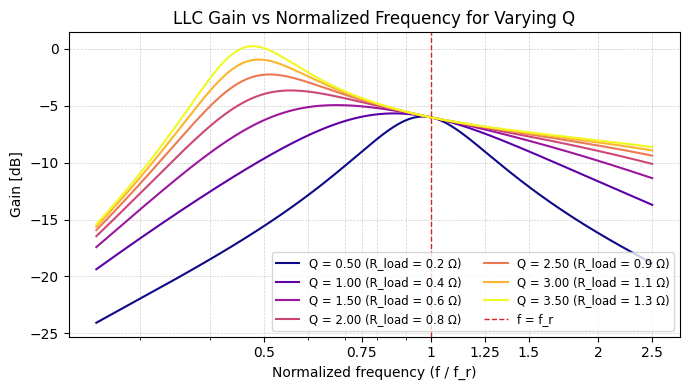

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

# === LLC tank parameters (edit these to match your design) ===
L_r = 2.4e-6    # series resonant inductance [H]
L_m = 9.6e-6    # magnetizing inductance [H]
n_ps = 2.0      # primary / secondary turns ratio (Np/Ns)
f_r = 100e3     # desired resonant frequency [Hz]

# === Q factor sweep setup ===
Q_start = 0.5   # minimum Q factor
Q_stop = 3.5    # maximum Q factor
Q_step = 0.5   # step size for Q factor

omega_r = 2 * np.pi * f_r
# Derive the resonant capacitor from L_r and f_r
C_r = 1 / (omega_r ** 2 * L_r)

# === Frequency sweep setup ===
f_min = 0.25 * f_r
f_max = 2.5 * f_r
freq = np.logspace(np.log10(f_min), np.log10(f_max), 800)
normalized_freq = freq / f_r

def llc_gain(freq, L_r, L_m, C_r, n_ps, R_load):
    omega = 2 * np.pi * freq
    Z_lr = 1j * omega * L_r
    Z_cr = 1 / (1j * omega * C_r)
    Z_lm = 1j * omega * L_m
    Z_load_ref = np.inf if R_load is None else R_load * (n_ps ** 2)
    if np.isinf(Z_load_ref):
        Z_parallel = Z_lm
    else:
        Z_parallel = 1 / (1 / Z_lm + 1 / Z_load_ref)
    Z_series = Z_lr + Z_cr
    v_node_over_vin = Z_parallel / (Z_series + Z_parallel)
    v_sec_over_vin = v_node_over_vin / n_ps
    return np.abs(v_sec_over_vin)

Q_values = np.arange(Q_start, Q_stop + 0.5 * Q_step, Q_step)
colors = cm.plasma(np.linspace(0, 1, len(Q_values)))
sweep_data = []

plt.figure(figsize=(7, 4))
for color, Q in zip(colors, Q_values):
    # Q = R_ref / (omega_r * L_r), with R_ref = n_ps^2 * R_load
    R_load = (Q * omega_r * L_r) / (n_ps ** 2)
    gain = llc_gain(freq, L_r, L_m, C_r, n_ps, R_load)
    ratio_gain = gain
    db_gain = 20 * np.log10(gain)
    label = f"Q = {Q:.2f} (R_load = {R_load:.1f} Ω)"
    sweep_data.append({
        "normalized_freq": normalized_freq,
        "ratio_gain": ratio_gain,
        "db_gain": db_gain,
        "color": color,
        "label": label
    })
    plt.semilogx(normalized_freq, db_gain, color=color, label=label)

plt.axvline(1.0, color='tab:red', linestyle='--', linewidth=1, label='f = f_r')
ax = plt.gca()
tick_positions = np.array([0.5, 0.75, 1.0, 1.25, 1.5, 2.0, 2.5])
ax.set_xticks(tick_positions)
ax.set_xticklabels([f"{t:g}" for t in tick_positions])
plt.title('LLC Gain vs Normalized Frequency for Varying Q')
plt.xlabel('Normalized frequency (f / f_r)')
plt.ylabel('Gain [dB]')
plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.6)
plt.legend(loc='best', fontsize='small', ncol=2)
plt.tight_layout()
plt.show()


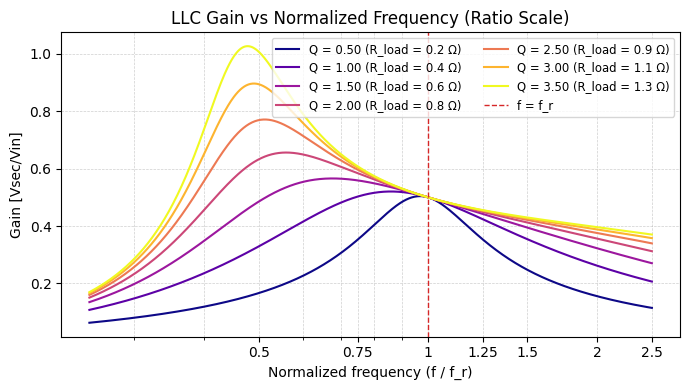

In [19]:
# Ratio (linear) gain view with the same log-spaced frequency axis
if 'sweep_data' not in globals():
    raise RuntimeError('Run the previous cell first to populate sweep_data.')

plt.figure(figsize=(7, 4))
for entry in sweep_data:
    plt.semilogx(entry['normalized_freq'], entry['ratio_gain'], color=entry['color'], label=entry['label'])

plt.axvline(1.0, color='tab:red', linestyle='--', linewidth=1, label='f = f_r')
ax = plt.gca()
tick_positions = [0.5, 0.75, 1.0, 1.25, 1.5, 2.0, 2.5]
ax.set_xticks(tick_positions)
ax.set_xticklabels([f"{t:g}" for t in tick_positions])
plt.title('LLC Gain vs Normalized Frequency (Ratio Scale)')
plt.xlabel('Normalized frequency (f / f_r)')
plt.ylabel('Gain [Vsec/Vin]')
plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.6)
plt.legend(loc='best', fontsize='small', ncol=2)
plt.tight_layout()
plt.show()
